In [1]:
import sys
from pathlib import Path
NOTEBOOKS = Path.cwd()                              # <-- Edit as needed
NEURALNET = NOTEBOOKS.parents[0]                    # <-- Edit as needed
BAMBOO_SETUP = NOTEBOOKS.parents[2]                 # <-- Edit as needed
Z_OUTPUT_eos = Path('/Users/antonett/Documents/HH Analysis/Z_OUTPUT_eos')   # <-- Edit as needed
sys.path.append(str((BAMBOO_SETUP/'src').resolve()))
import pandas as pd
pd.set_option('display.max_columns', None)  # Display all columns
pd.set_option('display.width', 1000)  # Set a larger width to fit the editor window
# pd.set_option('display.max_colwidth', None)  # Allow columns to be fully displayed
%load_ext autoreload

In [3]:
from NeuralNet.DataHandler import DataHandler
import logging
datahandler = DataHandler(
    workdir=Z_OUTPUT_eos/'2022_even_1013/Reco',
    tree_name='SL_res_2b_x',
    total_inputs= NEURALNET / 'input/vars40_new.txt',
    log_level=logging.DEBUG
)
# total_df = datahandler.start()
total_df_unprep = datahandler.load_data()
total_df_unprep = datahandler.fix_column_names_mismatch(total_df_unprep)
datahandler.data_inspection(total_df_unprep)
# datahandler.data_summary(total_df_unprep)
df = datahandler.preprocess_data(total_df_unprep)
datahandler.data_inspection(df)



Loading data...
	File: DY_dl_mll_50_1J
	File: DY_dl_mll_50_0J
	File: DY_dl_mll_10to50
	File: DY_dl_mll_50_2J
	File: bbWW_dl
	File: bbWW_sl
	File: bbtautau
	File: ZZ
	File: WW
	File: WZ
	File: Wjets_2J
	File: Wjets_0J
	File: Wjets_1J
	File: tbarWplus_sl
	File: tWminus_sl
	File: tWminus_dl
	File: tbarWplus_dl
	File: TTbar_dl
	File: TTbar_sl
	Total_df:
             event     genWeight  nAK4  nAK4_btag     lep0_pt  lep0_eta  lep0_phi  ak4_jet0_pt  ak4_jet0_eta  ak4_jet0_phi  ak4_jet1_pt  ak4_jet1_eta  ak4_jet1_phi  ak4_jet2_pt  ak4_jet2_eta  ak4_jet2_phi  ak4_btag0_pt  ak4_btag0_eta  ak4_btag0_phi  ak4_btag1_pt  ak4_btag1_eta  ak4_btag1_phi      met_pt   met_phi   bjets_mbb  bjets_dPhi  bjets_dEta  bjets_dR  bjets_pt_bb  trijet_mInv   trijet_pt  trijet_pt_rat     blnu_mT     blnu_pt  trijet_bijet_dR  trijet_bijet_dPhi  bjet_bijet_dR  bjet_bijet_dPhi     all_pt     all_mInv  all_jets_HT         mjj          File  Process
387977          18      3.805950     4          2   89.622681  1.1059

# Set up your model config

In [4]:
from NeuralNet.utils import ModelConfig
model_config = ModelConfig(
    name='multi_HH_ttbar_tW',
    type='multi',
    categorization={"HH": ["HH_bbWW"], "ttbar": ["ttbar"], "tW": ["tW"]},
    training_weight_sf={"HH_bbWW": 1.0, "ttbar": 8.0, "tW": 4.0},
    input_vars='All',
    architecture_in_yml=True,
    residual_network=True,
    hiddenlayers=[
        {"type": 'Dense', "units": 64, "activation": 'relu', "act_regularizer": {'l2': 1e-4}, "dropout_rate": 0.4},
        {"type": 'Dense', "units": 64, "activation": 'relu', "act_regularizer": {'l2': 1e-4}, "dropout_rate": 0.4},
        {"type": 'Dense', "units": 64, "activation": 'relu', "act_regularizer": {'l2': 1e-4}, "dropout_rate": 0.4}
    ],
    outputlayers=[
        {"type": 'Dense', "units": 3, "kernel_initializer": 'normal', "activation": 'softmax', "act_regularizer": {'l2': 1e-4}, "name": 'output'}
    ],
    compiler={"optimizer": 'adam', "lr": 0.001, "loss": 'categorical_crossentropy'},
    fit={"batch_size": 1024, "epochs": 35, "validation_split": 0.25}
)

In [32]:
%autoreload 2

# Run DNN

Initializing model: multi_HH_ttbar_tW
HH_bbWW
Total sum of genWeights for HH_bbWW: 137.84710693359375 
Total sum of sample_weights for HH_bbWW: 2340784.0 
ttbar
Total sum of genWeights for ttbar: 414462528.0 
Total sum of sample_weights for ttbar: 18726300.0 
tW
Total sum of genWeights for tW: 10632820.0 
Total sum of sample_weights for tW: 9363136.0 

Preprocessing input ...

Building model ...
Sumary of model compiled


Model: "multi_HH_ttbar_tW"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input (InputLayer)  │ (None, 40)        │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ normalization       │ (None, 40)        │          0 │ input[0][0]       │
│ (Normalization)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_0 (Dense)     │ (None, 64)        │      2,624 │ normalization[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 64)        │        256 │ layer_0[0][0]     │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 64)        │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_1 (Dense)     │ (None, 64)        │      4,160 │ dropout[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64)        │        256 │ layer_1[0][0]     │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 64)        │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_2 (Add)         │ (None, 64)        │          0 │ dropout_1[0][0],  │
│                     │                   │            │ dropout[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_2 (Dense)     │ (None, 64)        │      4,160 │ add_2[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64)        │        256 │ layer_2[0][0]     │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 64)        │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ output (Dense)      │ (None, 3)         │        195 │ dropout_2[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 11,907 (46.51 KB)

 Trainable params: 11,523 (45.01 KB)

...

None

Training model ...


Epoch 1/35
1372/1372 ━━━━━━━━━━━━━━━━━━━━ 14s 8ms/step - accuracy: 0.7381 - auc_pr: 0.7312 - auc_roc: 0.8581 - f1_score_macro: 0.3481 - f1_score_micro: 0.7381 - loss: 15.4961 - precision: 0.7936 - precision_HH: 0.0098 - precision_tW: 0.3511 - precision_ttbar: 0.8648 - recall: 0.5699 - recall_HH: 0.0575 - recall_tW: 0.0786 - recall_ttbar: 0.6578 - val_accuracy: 0.8480 - val_auc_pr: 0.8373 - val_auc_roc: 0.9332 - val_f1_score_macro: 0.3669 - val_f1_score_micro: 0.8480 - val_loss: 10.9956 - val_precision: 0.8553 - val_precision_HH: 0.0700 - val_precision_tW: 0.7013 - val_precision_ttbar: 0.8592 - val_recall: 0.8331 - val_recall_HH: 0.1250 - val_recall_tW: 0.0357 - val_recall_ttbar: 0.9751 - learning_rate: 0.0010
Epoch 2/35
1372/1372 ━━━━━━━━━━━━━━━━━━━━ 11s 8ms/step - accuracy: 0.8327 - auc_pr: 0.8074 - auc_roc: 0.9219 - f1_score_macro: 0.3715 - f1_score_micro: 0.8327 - loss: 11.0822 - precision: 0.8430 - precision_HH: 0.0282 - precision_tW: 0.4350 - precision_ttbar: 0.8622 - recall: 0.81


Saving model info ...

Evaluating model and predicting ...
	Model metrics: {'accuracy': 0.8422324061393738, 'auc_pr': 0.8516741991043091, 'auc_roc': 0.9377408623695374, 'f1_score_macro': 0.42411255836486816, 'f1_score_micro': 0.842232346534729, 'loss': 0.5295276641845703, 'precision': 0.8519377112388611, 'precision_HH': 0.06348749995231628, 'precision_tW': 0.5313459634780884, 'precision_ttbar': 0.8750172853469849, 'recall': 0.8226813077926636, 'recall_HH': 0.265625, 'recall_tW': 0.16794438660144806, 'recall_ttbar': 0.939289391040802}


14630/14630 ━━━━━━━━━━━━━━━━━━━━ 5s 311us/step


	Predictions:
      event  Class_HH  Class_ttbar  Class_tW  Score_HH  Score_ttbar  Score_tW
0  22787012       0.0          1.0       0.0  0.041379     0.683157  0.275464
1   9484420       0.0          1.0       0.0  0.076128     0.666133  0.257740
2   7718580       0.0          1.0       0.0  0.812552     0.106739  0.080708
3  67595314       0.0          1.0       0.0  0.016679     0.705406  0.277915
4  15967516       0.0          1.0       0.0  0.027094     0.728674  0.244233


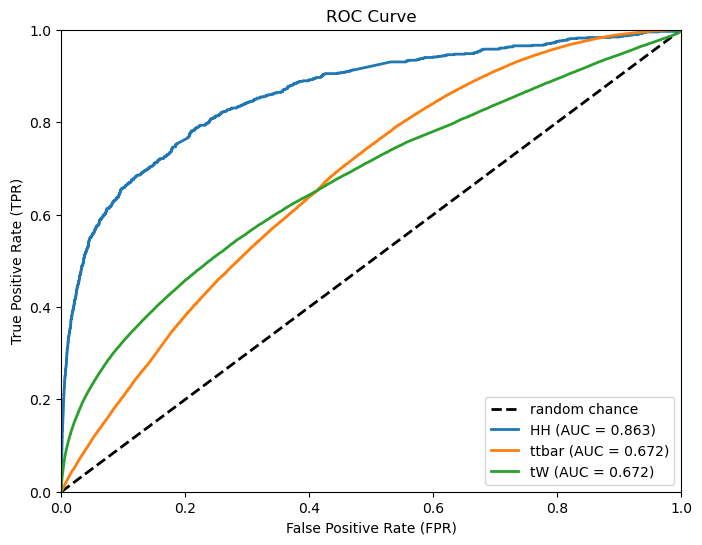

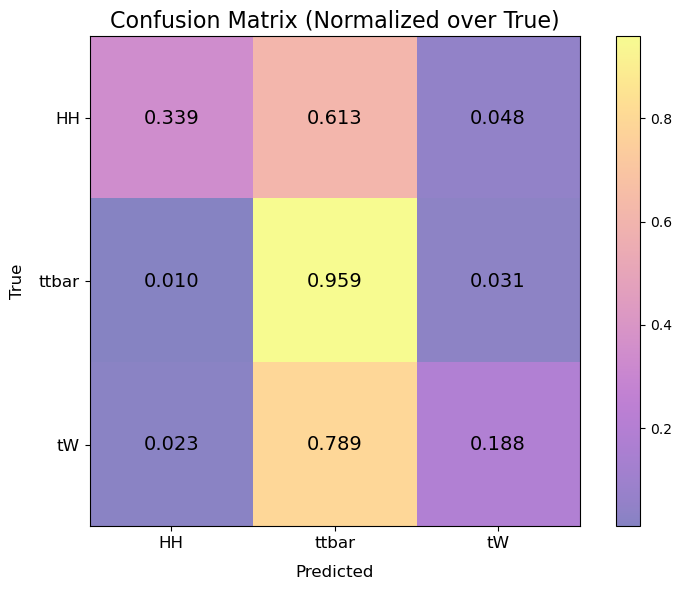

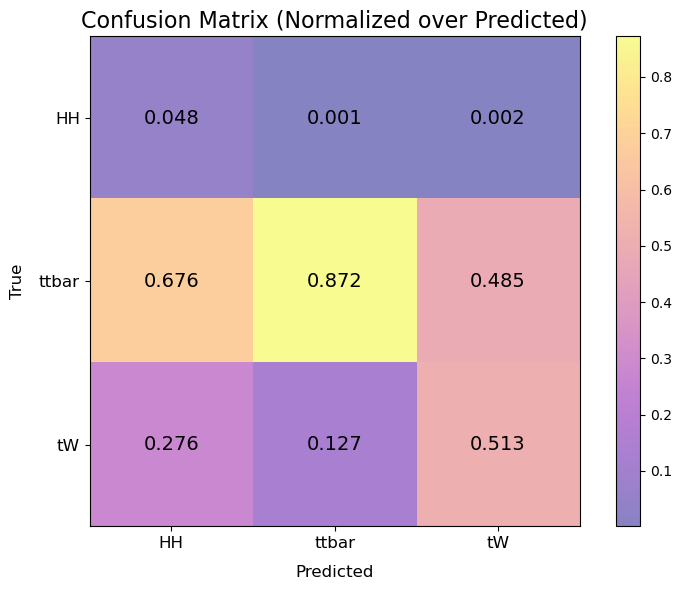

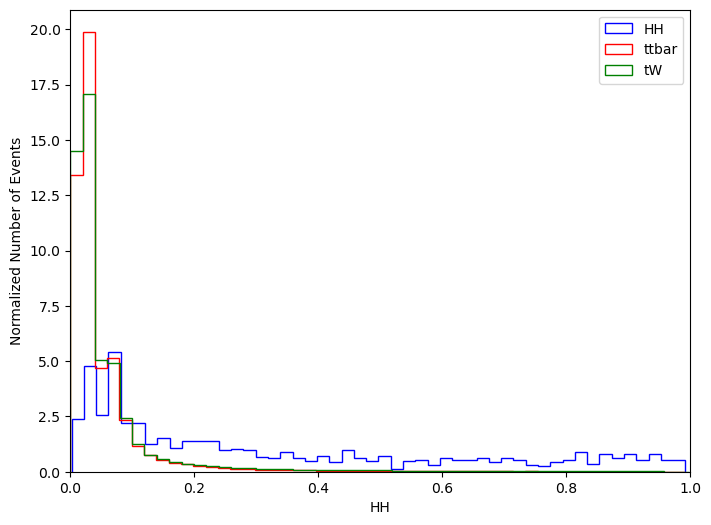

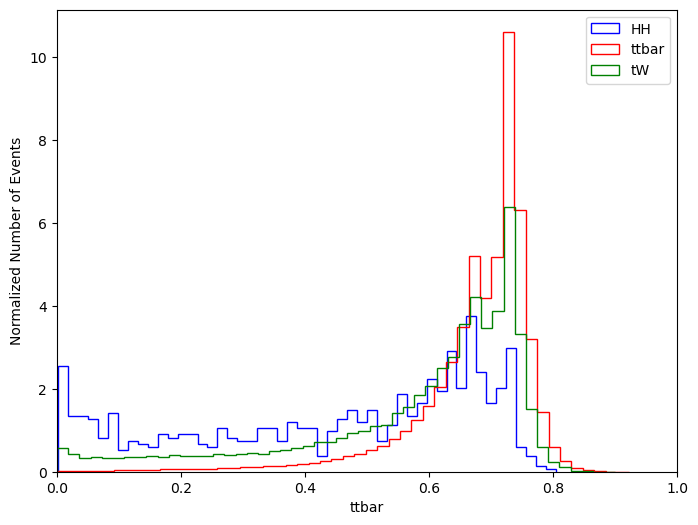

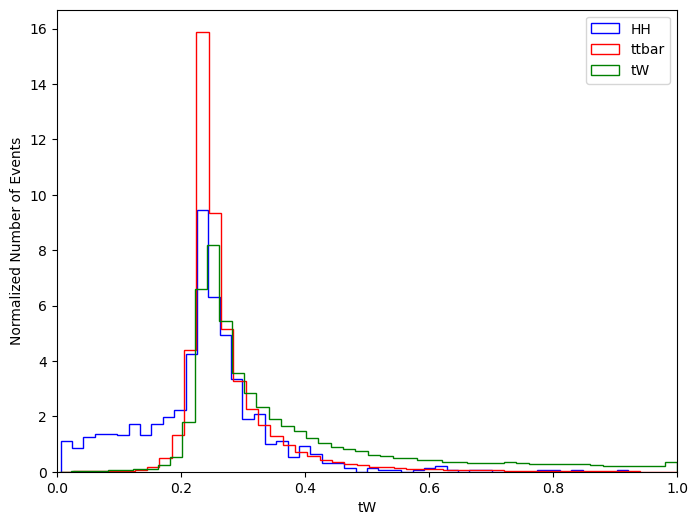

In [5]:
from NeuralNet.DNNModel import DNNModel, draw_all_stats
import NeuralNet.utils as utils

DNN = DNNModel(model_config=model_config, modeldir= NOTEBOOKS/'model_custom', log_level=logging.DEBUG)
model_df = DNN.set_model_df_from_total_df(df)
X_train, X_test, Y_train, Y_test, evs_test, sw_train = DNN.Full_Splitting(model_df)
input_layer, normalized_input = DNN.input_preprocessing(X_train)

DNN.build_model(input_layer=input_layer, normalized_input=normalized_input, fixed_random_seed=True)
DNN.train_model(X_train, Y_train, sw_train)
DNN.save_model_info(X_train.columns, Y_train, Y_test)
output_df, model_metrics = DNN.evaluate_and_predict(X_test, Y_test, evs_test)
cm_norm_true, cm_norm_pred, diag_names = draw_all_stats(DNN_type=DNN.type, history=DNN.history, output_df=output_df, modeldir=DNN.modeldir, classes=DNN.classes)

In [17]:
%autoreload 2

In [44]:
from tensorflow.keras.layers import Normalization
import numpy as np

# Convert DataFrame to numpy array and get input shape
X_train_array = X_train.to_numpy()
input_shape = (X_train.shape[1],)

# Create and adapt the normalizer
normalizer = Normalization(input_shape=input_shape)
normalizer.adapt(X_train_array)

# Get normalization parameters and convert to regular numpy arrays
mean = np.array(normalizer.mean.numpy()).flatten()
variance = np.array(normalizer.variance.numpy()).flatten()
std = np.sqrt(variance)

# Calculate normalized values using broadcasting
X_normalized = pd.DataFrame(
    (X_train_array - mean) / std,
    columns=X_train.columns
)

/Users/antonett/anaconda3/envs/myenv/lib/python3.12/site-packages/keras/src/layers/preprocessing/tf_data_layer.py:19: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [36]:
X_train.describe().round(3)

,nAK4,nAK4_btag,lep0_pt,lep0_eta,lep0_phi,ak4_jet0_pt,ak4_jet0_eta,ak4_jet0_phi,ak4_jet1_pt,ak4_jet1_eta,ak4_jet1_phi,ak4_jet2_pt,ak4_jet2_eta,ak4_jet2_phi,ak4_btag0_pt,ak4_btag0_eta,ak4_btag0_phi,ak4_btag1_pt,ak4_btag1_eta,ak4_btag1_phi,met_pt,met_phi,bjets_mbb,bjets_dPhi,bjets_dEta,bjets_dR,bjets_pt_bb,trijet_mInv,trijet_pt,trijet_pt_rat,blnu_mT,blnu_pt,trijet_bijet_dR,trijet_bijet_dPhi,bjet_bijet_dR,bjet_bijet_dPhi,all_pt,all_mInv,all_jets_HT,mjj
count,1872627.000,1872627.000,1872627.000,1872627.000,1872627.000,1872627.000,1872627.000,1872627.000,1872627.000,1872627.000,1872627.000,1872627.000,1872627.000,1872627.000,1872627.000,1872627.000,1872627.000,1872627.000,1872627.000,1872627.000,1872627.000,1872627.000,1872627.000,1872627.000,1872627.000,1872627.000,1872627.000,1872627.000,1872627.000,1872627.000,1872627.000,1872627.000,1872627.000,1872627.000,1872627.000,1872627.000,1872627.000,1872627.000,1872627.000,1872627.000
mean,4.676,2.072,63.342,0.000,-0.004,139.410,-0.000,0.003,91.244,-0.000,0.001,62.917,-0.000,-0.002,109.640,-0.000,-0.000,59.954,0.001,-0.001,79.401,0.003,171.439,-0.004,0.001,2.362,98.670,276.293,168.410,0.701,273.083,157.455,0.799,0.001,1.993,0.001,41.717,730.801,363.378,144.579
std,0.906,0.270,41.759,1.078,1.815,86.539,1.134,1.814,49.199,1.141,1.816,29.746,1.175,1.815,64.902,1.077,1.816,33.110,1.127,1.815,55.883,1.817,114.012,2.088,1.381,0.828,65.983,186.472,95.432,0.184,113.584,93.293,0.690,0.742,0.886,1.547,37.497,357.447,179.071,135.763
min,4.000,2.000,15.000,-2.500,-3.142,26.578,-2.400,-3.142,25.359,-2.400,-3.142,25.016,-2.400,-3.142,25.047,-2.400,-3.142,25.016,-2.400,-3.142,0.049,-3.142,12.803,-3.142,-4.781,0.378,0.072,27.437,3.581,0.029,52.767,0.172,0.001,-3.142,0.002,-3.142,0.042,169.577,104.828,11.726
25%,4.000,2.000,35.970,-0.790,-1.576,87.562,-0.855,-1.563,60.750,-0.857,-1.571,43.344,-0.894,-1.574,69.500,-0.795,-1.570,36.938,-0.842,-1.572,41.955,-1.572,97.540,-2.057,-0.962,1.772,56.661,161.886,107.432,0.573,199.447,96.430,0.334,-0.349,1.334,-1.301,18.863,496.257,248.969,71.927
50%,4.000,2.000,52.178,0.001,-0.009,116.812,0.000,0.002,79.750,-0.002,-0.001,56.000,-0.000,-0.005,95.625,-0.000,-0.005,51.406,0.002,-0.004,67.573,0.005,144.837,-0.012,0.001,2.454,87.820,216.994,148.071,0.720,249.353,139.247,0.584,0.001,1.910,0.002,31.902,638.410,319.625,97.576
75%,5.000,2.000,77.788,0.792,1.569,161.875,0.853,1.573,107.312,0.856,1.575,74.062,0.892,1.571,131.500,0.792,1.575,73.125,0.844,1.571,102.261,1.581,213.864,2.052,0.964,2.974,124.937,331.156,203.913,0.850,317.522,196.400,1.020,0.350,2.566,1.303,51.720,856.923,424.453,170.641
max,13.000,6.000,1376.128,2.500,3.142,2696.000,2.400,3.142,1953.000,2.400,3.142,1119.000,2.400,3.142,2696.000,2.400,3.142,1314.000,2.400,3.142,3828.651,3.142,4018.068,3.142,4.791,5.704,1860.764,5438.138,2737.176,1.000,4036.089,3920.751,8.795,3.142,10.156,3.142,3776.636,7973.377,5215.375,4661.124


In [35]:
X_normalized.describe().round(3)

,nAK4,nAK4_btag,lep0_pt,lep0_eta,lep0_phi,ak4_jet0_pt,ak4_jet0_eta,ak4_jet0_phi,ak4_jet1_pt,ak4_jet1_eta,ak4_jet1_phi,ak4_jet2_pt,ak4_jet2_eta,ak4_jet2_phi,ak4_btag0_pt,ak4_btag0_eta,ak4_btag0_phi,ak4_btag1_pt,ak4_btag1_eta,ak4_btag1_phi,met_pt,met_phi,bjets_mbb,bjets_dPhi,bjets_dEta,bjets_dR,bjets_pt_bb,trijet_mInv,trijet_pt,trijet_pt_rat,blnu_mT,blnu_pt,trijet_bijet_dR,trijet_bijet_dPhi,bjet_bijet_dR,bjet_bijet_dPhi,all_pt,all_mInv,all_jets_HT,mjj
count,1872627.000,1872627.000,1872627.000,1872627.000,1872627.000,1872627.000,1872627.000,1872627.000,1872627.000,1872627.000,1872627.000,1872627.000,1872627.000,1872627.000,1872627.000,1872627.000,1872627.000,1872627.000,1872627.000,1872627.000,1872627.000,1872627.000,1872627.000,1872627.000,1872627.000,1872627.000,1872627.000,1872627.000,1872627.000,1872627.000,1872627.000,1872627.000,1872627.000,1872627.000,1872627.000,1872627.000,1872627.000,1872627.000,1872627.000,1872627.000
mean,-0.000,0.000,-0.000,0.000,-0.000,0.000,-0.000,0.000,0.000,0.000,0.000,-0.000,0.000,0.000,-0.000,0.000,-0.000,0.000,0.000,-0.000,0.000,-0.000,0.000,0.000,-0.000,-0.000,-0.000,0.000,0.000,-0.000,-0.000,0.000,0.000,0.000,-0.000,0.000,-0.000,-0.000,0.000,0.000
std,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000
min,-0.746,-0.265,-1.158,-2.320,-1.729,-1.304,-2.115,-1.734,-1.339,-2.103,-1.731,-1.274,-2.042,-1.730,-1.303,-2.229,-1.730,-1.055,-2.130,-1.730,-1.420,-1.731,-1.391,-1.503,-3.464,-2.396,-1.494,-1.335,-1.727,-3.661,-1.940,-1.686,-1.156,-4.237,-2.248,-2.032,-1.111,-1.570,-1.444,-0.979
25%,-0.746,-0.265,-0.655,-0.734,-0.866,-0.599,-0.754,-0.863,-0.620,-0.750,-0.866,-0.658,-0.761,-0.866,-0.618,-0.738,-0.865,-0.695,-0.748,-0.865,-0.670,-0.867,-0.648,-0.983,-0.697,-0.712,-0.637,-0.614,-0.639,-0.697,-0.648,-0.654,-0.674,-0.472,-0.744,-0.841,-0.609,-0.656,-0.639,-0.535
50%,-0.746,-0.265,-0.267,0.001,-0.003,-0.261,0.000,-0.001,-0.234,-0.001,-0.001,-0.233,0.000,-0.002,-0.216,-0.000,-0.003,-0.258,0.001,-0.001,-0.212,0.001,-0.233,-0.004,0.000,0.111,-0.164,-0.318,-0.213,0.102,-0.209,-0.195,-0.312,-0.001,-0.094,0.001,-0.262,-0.258,-0.244,-0.346
75%,0.358,-0.265,0.346,0.734,0.867,0.260,0.752,0.866,0.327,0.750,0.867,0.375,0.760,0.867,0.337,0.736,0.868,0.398,0.748,0.866,0.409,0.868,0.372,0.984,0.697,0.739,0.398,0.294,0.372,0.815,0.391,0.417,0.321,0.471,0.647,0.841,0.267,0.353,0.341,0.192
max,9.187,14.538,31.437,2.319,1.733,29.543,2.116,1.730,37.841,2.104,1.729,35.503,2.043,1.732,39.850,2.229,1.730,37.875,2.128,1.731,67.091,1.727,33.739,1.506,3.469,4.035,26.705,27.682,26.917,1.630,33.130,40.339,11.583,4.234,9.218,2.030,99.605,20.262,27.095,33.268


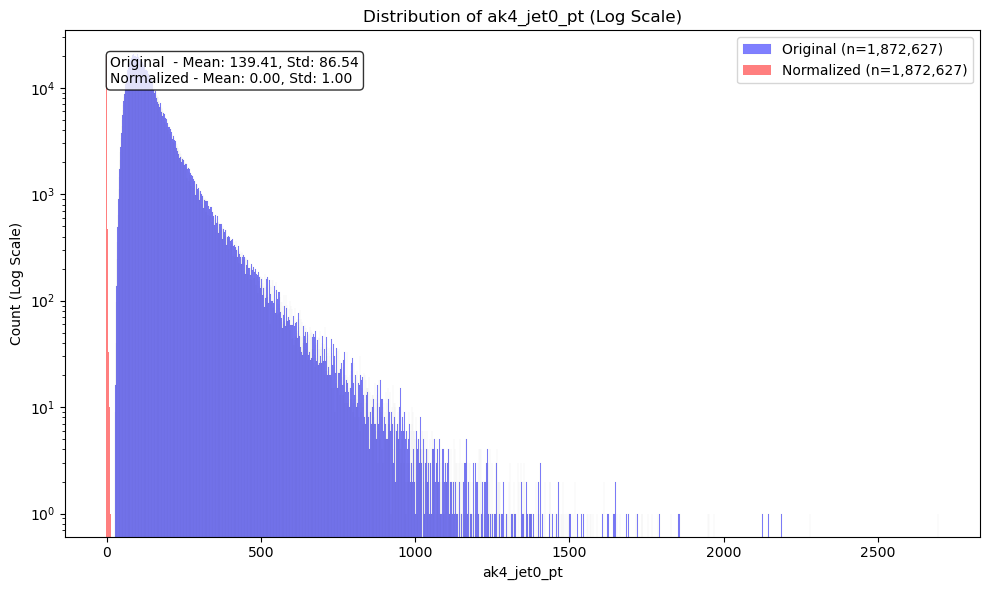

In [51]:
def plot_feature_comparison(X_train, X_normalized, feature_name):
    import matplotlib.pyplot as plt
    import seaborn as sns
    
    # Create figure
    plt.figure(figsize=(10, 6))
    
    sns.histplot(data=X_train, x=feature_name, label=f'Original (n={len(X_train):,})', alpha=0.5, color='blue')
    sns.histplot(data=X_normalized, x=feature_name, label=f'Normalized (n={len(X_normalized):,})', alpha=0.5, color='red')
    
    plt.title(f'Distribution of {feature_name} (Log Scale)')
    plt.xlabel(f'{feature_name}')
    plt.ylabel('Count (Log Scale)')
    plt.yscale('log')  # Set y-axis to log scale
    plt.legend()
    
    # Add statistics text
    stats_text = (
        f'Original  - Mean: {X_train[feature_name].mean():.2f}, Std: {X_train[feature_name].std():.2f}\n'
        f'Normalized - Mean: {X_normalized[feature_name].mean():.2f}, Std: {X_normalized[feature_name].std():.2f}'
    )
    plt.text(0.05, 0.95, stats_text, transform=plt.gca().transAxes,
             verticalalignment='top', bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
    
    plt.tight_layout()
    plt.show()

plot_feature_comparison(X_train, X_normalized, 'ak4_jet0_pt')

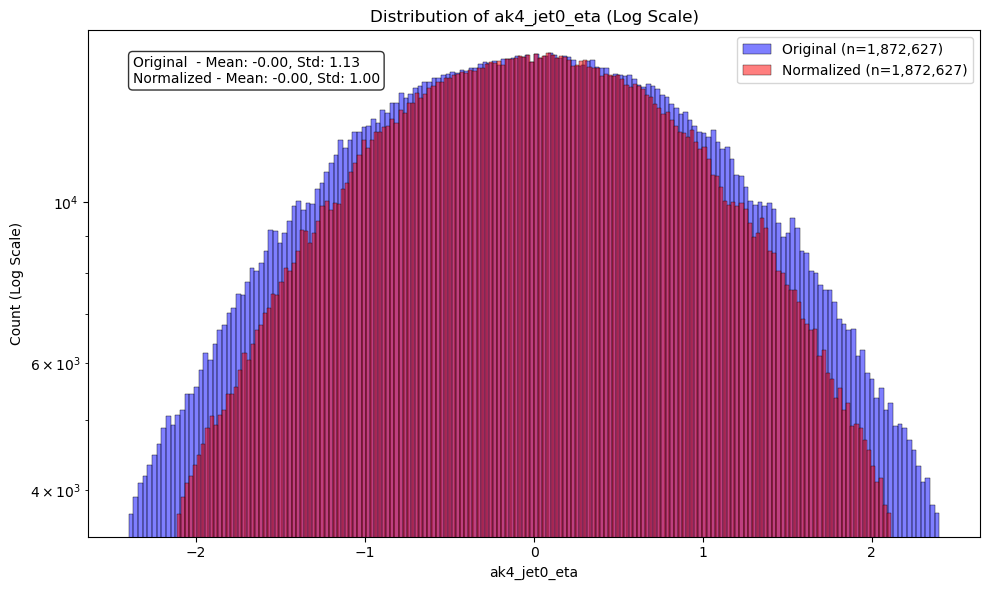

In [52]:
plot_feature_comparison(X_train, X_normalized, 'ak4_jet0_eta')